# Exploration des données et construction de la cible NPS

Notebook d'accompagnement de l'étude (phases 2 et 3 de CRISP-DM). Il rejoue les analyses à partir des
fonctions de `src/` : les chiffres sont ceux des rapports `reports/02_comprehension_donnees.md` et
`reports/03_preparation_donnees.md`. Lecture recommandée : d'abord ces rapports, puis ce notebook pour
manipuler les données.

**Convention** : aucune constante recopiée — tout vient de `config.yaml` et des données brutes.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
RACINE = Path.cwd().resolve()
if not (RACINE / "src").exists():
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
from src.data import charger_config, charger_tables, joindre, controler_qualite, preparer, registre_fuites
from src.features import construire, colonnes_modele, HYPOTHESES_DERIVEES
from src.target import construire_cibles, nps, ORDRE
from src.protocol import decouper, diagnostic
cfg = charger_config(); print("seed :", cfg["seed"])

seed : 42


## 1. Sources et jointure

Cinq tables, jointure interne sur `Customer ID`, population rattachée par `Zip Code`. Porte de contrôle : 7 043 lignes.

In [2]:
tables = charger_tables(cfg)
for k, t in tables.items():
    print(f"{k:14s} {t.shape}")
df_raw = joindre(tables)
print("\nAprès jointure :", df_raw.shape)
df_raw.head(3).T

demographics   (7043, 9)
location       (7043, 9)
population     (1671, 3)
services       (7043, 30)
status         (7043, 11)

Après jointure : (7043, 51)


,0,1,2
Customer ID,8779-QRDMV,7495-OOKFY,1658-BYGOY
Gender,Male,Female,Male
Age,78,74,71
Under 30,No,No,No
Senior Citizen,Yes,Yes,Yes
Married,No,Yes,No
Dependents,No,Yes,Yes
Number of Dependents,0,1,3
Country,United States,United States,United States
State,California,California,California


## 2. Qualité — cinq contrôles

Manquants structurels (le vide a un sens), doublons, aberrantes (conservées), cohérence interne, colonnes constantes.

In [3]:
q = controler_qualite(df_raw)
print("Manquants :", q["manquants"])
print("Doublons id :", q["doublons_id"], "| doublons lignes :", q["doublons_lignes"])
print("Aberrantes (IQR x 1,5) :", q["aberrantes"])
print("Ancienneté nulle :", q["anciennete_zero"], "| incohérences facturation :", q["incoherence_facturation"])
print("Constantes :", q["constantes"])

Manquants : {'Churn Category': 5174, 'Churn Reason': 5174, 'Offer': 3877, 'Internet Type': 1526}
Doublons id : 0 | doublons lignes : 0
Aberrantes (IQR x 1,5) : {'Tenure in Months': 0, 'Monthly Charge': 0, 'Total Charges': 0, 'Total Revenue': 21, 'Avg Monthly GB Download': 362}
Ancienneté nulle : 0 | incohérences facturation : 2
Constantes : ['Country', 'State']


## 3. La cible brute : `Satisfaction Score`

Le fait fondateur du projet : satisfaction 1–2 → 100 % de départs, 4–5 → 0 %. La note 3 est la seule zone d'incertitude.

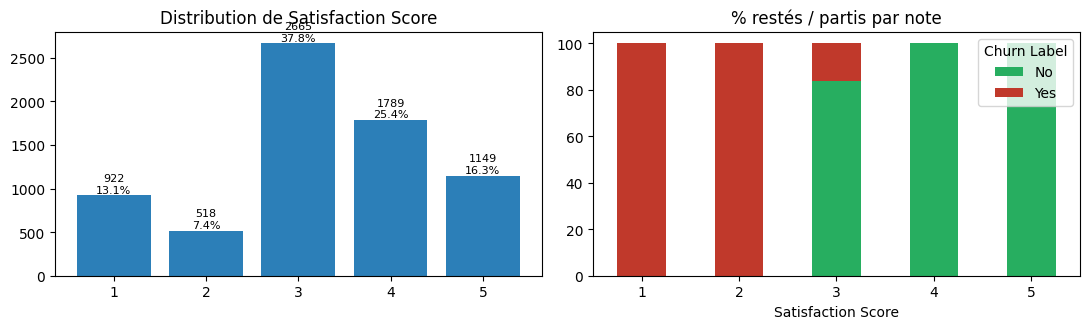

Churn Label,No,Yes,% départ
Satisfaction Score,,,
1,0,922,100.0
2,0,518,100.0
3,2236,429,16.1
4,1789,0,0.0
5,1149,0,0.0


In [4]:
cible = cfg["colonnes"]["cible"]
dist = df_raw[cible].value_counts().sort_index()
ct = pd.crosstab(df_raw[cible], df_raw["Churn Label"])
ct["% départ"] = (ct["Yes"] / ct.sum(axis=1) * 100).round(1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(dist.index.astype(str), dist.values, color="#2c7fb8"); axes[0].set_title("Distribution de Satisfaction Score")
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 30, f"{v}\n{v/len(df_raw):.1%}", ha="center", fontsize=8)
(pd.crosstab(df_raw[cible], df_raw["Churn Label"], normalize="index") * 100).plot(kind="bar", stacked=True, ax=axes[1], color=["#27ae60", "#c0392b"], rot=0)
axes[1].set_title("% restés / partis par note"); plt.tight_layout(); plt.show()
ct

## 4. Registre de fuites

Toute colonne liée au churn est une fuite (conséquence, disponibilité, modèle amont). On le **mesure** par
information mutuelle plutôt que de l'affirmer.

In [5]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
reg = registre_fuites(cfg)
for k, v in reg.items():
    print(f"{k:22s} {v}")
df, _ = preparer(cfg)
cand = ["Churn Value", "Churn Score", "CLTV", "Customer Status", "Contract", "Tenure in Months", "Monthly Charge", "Number of Referrals", "Offer", "Internet Type"]
Xmi = pd.DataFrame({c: LabelEncoder().fit_transform(df[c].astype(str)) if df[c].dtype == object else df[c].fillna(df[c].median()) for c in cand})
mi = pd.Series(mutual_info_classif(Xmi, df[cible], random_state=cfg["seed"]), index=cand).sort_values(ascending=False)
mi.round(3)

cible                  ['Satisfaction Score']
fuite_consequence      ['Churn Label', 'Churn Value', 'Customer Status']
fuite_disponibilite    ['Churn Category', 'Churn Reason']
fuite_modele_amont     ['Churn Score', 'CLTV']
techniques             ['Customer ID', 'Count', 'Quarter', 'Country', 'State', 'ID', 'Lat Long']
audit_seulement        ['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population']


Customer Status        0.421
Churn Value            0.416
Churn Score            0.281
Contract               0.092
Number of Referrals    0.058
Internet Type          0.052
Tenure in Months       0.046
Monthly Charge         0.045
Offer                  0.033
CLTV                   0.016
dtype: float64

## 5. La quasi-expérience `Offer`

Les clients ayant reçu l'offre E partent deux fois plus. Biais d'indication : l'offre a été proposée à des clients déjà fragiles. Aucune lecture causale.

In [6]:
df.groupby("Offer").agg(clients=("Customer ID", "count"), taux_depart=("Churn Value", "mean"), satisfaction=(cible, "mean")).round(3).sort_values("taux_depart")

,clients,taux_depart,satisfaction
Offer,,,
Offer A,520,0.067,3.546
Offer B,824,0.123,3.478
Offer C,415,0.229,3.316
Offer D,602,0.267,3.246
Aucune offre,3877,0.271,3.238
Offer E,805,0.529,2.810


## 6. Variables explicatives et dérivées

Chaque variable dérivée est adossée à une hypothèse métier (`src/features.py`).

In [7]:
df = construire(df)
num, cat = colonnes_modele(df, cfg)
print(len(num), "numériques :", num)
print(len(cat), "catégorielles :", cat)
pd.DataFrame([{"variable": k, "hypothèse": v} for k, v in HYPOTHESES_DERIVEES.items()])

18 numériques : ['Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'nb_services', 'charge_par_service', 'a_recu_offre', 'a_eu_remboursement', 'a_frais_supplementaires', 'revenu_par_mois', 'a_parraine', 'paiement_automatique']
17 catégorielles : ['Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'tranche_anciennete']


,variable,hypothèse
0,nb_services,intensité de la relation commerciale : plus de...
1,charge_par_service,perception du rapport qualité-prix : ce que co...
2,tranche_anciennete,l'insatisfaction d'un nouveau client (attentes...
3,a_recu_offre,un geste commercial a-t-il été fait ? (indicat...
4,a_eu_remboursement,trace d'un incident de facturation reconnu par...
5,a_frais_supplementaires,trace d'un dépassement de forfait — friction t...
6,revenu_par_mois,"intensité économique moyenne de la relation, i..."
7,a_parraine,proxy comportemental direct de la recommandati...
8,paiement_automatique,auto-pay (énoncé § 4.3) : un paiement automati...


## 7. Construction de la cible : trois mappings et arbitrage empirique des « 3 »

Le mapping de l'énoncé (M1) donne un NPS très négatif parce qu'il envoie les 2 665 clients à « 3 » chez les
détracteurs. Un modèle entraîné sur les seuls extrêmes (1–2 vs 4–5) dit à qui ils ressemblent.

In [8]:
cibles, arb = construire_cibles(df, cfg, cfg["seed"])
print({m: nps(cibles[m]) for m in ("M1", "M2", "M3")})
print("Extrêmes :", arb["n_extremes"], "| ambigus :", arb["n_ambigus"], "| exactitude sur extrêmes (CV) :", arb["exactitude_sur_extremes"])
print("Part des 3 penchant détracteur :", arb["part_3_vers_detracteur"], "-> le bloc rejoint :", arb["destination_des_3"])
pd.DataFrame({m: cibles[m].value_counts(normalize=True).reindex(ORDRE).round(3) for m in ("M1", "M2", "M3")})

{'M1': -42.0, 'M2': -4.1, 'M3': 21.3}
Extrêmes : 4378 | ambigus : 2665 | exactitude sur extrêmes (CV) : 0.8013
Part des 3 penchant détracteur : 0.2788 -> le bloc rejoint : Passif


,M1,M2,M3
Detracteur,0.583,0.204,0.204
Passif,0.254,0.632,0.378
Promoteur,0.163,0.163,0.417


## 8. Le protocole 15 / 85 : trois mécanismes de non-réponse

Sous S3 (MNAR), les extrêmes répondent plus : le modèle apprend sur une population qui ne ressemble pas à celle qu'il scorera.

In [9]:
pd.DataFrame([diagnostic(df, cfg, decouper(df, cfg, sc, cfg["seed"])) for sc in cfg["protocole"]["scenarios"]])

,scenario,taux_reponse,satisfaction_moyenne_base,satisfaction_moyenne_repondants,ecart,part_extremes_base,part_extremes_repondants
0,S1_MCAR,0.1516,3.245,3.230,-0.015,0.3676,0.3970
1,S2_MAR,0.1541,3.245,3.316,0.071,0.3676,0.3300
2,S3_MNAR,0.1533,3.245,3.373,0.128,0.3676,0.7139


## Suite

La modélisation (quinze modèles, sélection sans regarder le test), l'évaluation et le déploiement sont
exécutés par `python -m src.run` et documentés dans `reports/04_modelisation.md` et suivants. Ce notebook
s'arrête volontairement là : le pipeline est la source de vérité, le notebook une fenêtre dessus.